Using device: cuda
Model definition loaded.
Using downloaded and verified file: data/organamnist.npz
Loaded 17778 test samples.


/tmp/ipykernel_327598/3933029326.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


Model loaded successfully.
FGSM attack function ready.
Image 1: Label 8
Image 2: Label 8
Adversarial examples generated.


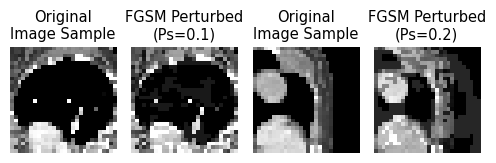

Plot saved to results/fgsm_visual_comparison.pdf


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torchvision import transforms
from data_downloader import _choose_dataclass

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# CapsNet Model Definition
def squash(tensor, dim=-1, eps=1e-9):
    squared_norm = (tensor ** 2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1.0 + squared_norm)
    return scale * tensor / torch.sqrt(squared_norm + eps)

class ConvLayer(nn.Module):
    def __init__(self, in_channels=1, out_channels=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(p=0.1),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(p=0.1),
            nn.Conv2d(in_channels=128, out_channels=out_channels, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.features(x)

class PrimaryCaps(nn.Module):
    def __init__(self, num_capsules=8, in_channels=256, out_channels=32, kernel_size=9, stride=2, num_routes=32*6*6):
        super().__init__()
        self.num_routes = num_routes
        self.capsules = nn.ModuleList([
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=0)
            for _ in range(num_capsules)])
    def forward(self, x):
        u = torch.stack([capsule(x) for capsule in self.capsules], dim=1)
        u = u.view(x.size(0), self.num_routes, -1)
        return squash(u, dim=-1)

class DigitCaps(nn.Module):
    def __init__(self, num_capsules=11, num_routes=32*6*6, in_channels=8, out_channels=24, routing_iters=3):
        super().__init__()
        self.in_channels, self.num_routes, self.num_capsules = in_channels, num_routes, num_capsules
        self.routing_iters = routing_iters
        self.W = nn.Parameter(torch.randn(1, num_routes, num_capsules, out_channels, in_channels) * 0.01)
    def forward(self, x):
        B = x.size(0)
        x = x[:, :, None, :, None]
        W = self.W.expand(B, -1, -1, -1, -1)
        u_hat = torch.matmul(W, x)
        b_ij = torch.zeros(B, self.num_routes, self.num_capsules, 1, 1, device=x.device)
        for i in range(self.routing_iters):
            c_ij = F.softmax(b_ij, dim=2)
            s_j = (c_ij * u_hat).sum(dim=1, keepdim=True)
            v_j = squash(s_j, dim=3)
            if i < self.routing_iters - 1:
                a_ij = (u_hat * v_j).sum(dim=3, keepdim=True)
                b_ij = b_ij + a_ij
        return v_j.squeeze(1).squeeze(-1)

class Decoder(nn.Module):
    def __init__(self, input_size=28, num_capsules=11, dim_capsule=24):
        super().__init__()
        self.input_size = input_size
        in_features = num_capsules * dim_capsule
        self.reconstruction = nn.Sequential(
            nn.Linear(in_features, 512), nn.ReLU(inplace=True),
            nn.Linear(512, 1024), nn.ReLU(inplace=True),
            nn.Linear(1024, input_size * input_size), nn.Sigmoid(),
        )
    def forward(self, digit_caps_output, labels=None):
        lengths = torch.norm(digit_caps_output, dim=2)
        if labels is None:
            _, max_idx = lengths.max(dim=1)
            labels = torch.eye(lengths.size(1), device=digit_caps_output.device)[max_idx]
        masked = (digit_caps_output * labels.unsqueeze(2)).view(digit_caps_output.size(0), -1)
        recon = self.reconstruction(masked)
        return recon.view(-1, 1, self.input_size, self.input_size)

class CapsNet(nn.Module):
    def __init__(self, img_size=28, num_classes=11):
        super().__init__()
        self.num_classes = num_classes
        self.conv = ConvLayer(in_channels=1, out_channels=256)
        self.primary = PrimaryCaps(num_capsules=8, in_channels=256, out_channels=32, kernel_size=9, stride=2, num_routes=32*6*6)
        self.digits = DigitCaps(num_capsules=num_classes, num_routes=32*6*6, in_channels=8, out_channels=24, routing_iters=3)
        self.decoder = Decoder(input_size=img_size, num_capsules=num_classes, dim_capsule=24)
        self.mse = nn.MSELoss()
    def forward(self, x, labels=None):
        digs = self.digits(self.primary(self.conv(x)))
        recon = self.decoder(digs, labels)
        return digs, recon
    @staticmethod
    def margin_loss(digit_caps_output, one_hot_labels, m_plus=0.9, m_minus=0.1, lambda_=0.5):
        v = torch.norm(digit_caps_output, dim=2)
        loss = one_hot_labels * F.relu(m_plus - v)**2 + lambda_ * (1.0 - one_hot_labels) * F.relu(v - m_minus)**2
        return loss.sum(dim=1).mean()

print("Model definition loaded.")
# Load dataset
IMG_SIZE = 28
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[.5], std=[.5]),
])
font_size = 10.5
DATA_ROOT = Path("data/")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
DataClass = _choose_dataclass("axial")
test_ds = DataClass(split='test', transform=transform, download=True, root=str(DATA_ROOT))

print(f"Loaded {len(test_ds)} test samples.")

# Load model
model_path = "/home/ap1284@DS.UAH.edu/Atit/CapsNet/research/trained_models/fed_caps_niid_0.1_4clients_frac0.25.pth"
model = CapsNet(img_size=IMG_SIZE, num_classes=11).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully.")
# FGSM Attack Function
def fgsm_attack(model, image, label, epsilon):
    """Generate FGSM adversarial example"""
    image = image.clone().detach().to(device)
    image.requires_grad = True
    label = label.to(device)
    
    # Forward pass
    digs, _ = model(image.unsqueeze(0))
    
    # Create one-hot labels
    one_hot_label = F.one_hot(label, num_classes=model.num_classes).float()
    
    # Calculate loss
    loss = model.margin_loss(digs, one_hot_label.unsqueeze(0))
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Create adversarial example
    perturbed_image = image + epsilon * image.grad.sign()
    perturbed_image = torch.clamp(perturbed_image, -1, 1)
    
    return perturbed_image.detach()

print("FGSM attack function ready.")
# Select two random images
np.random.seed(5)
idx1 = np.random.randint(0, len(test_ds))
idx2 = np.random.randint(0, len(test_ds))

image1, label1 = test_ds[idx1]
image2, label2 = test_ds[idx2]

# Convert labels to scalar
label1 = torch.as_tensor(label1).squeeze().long()
label2 = torch.as_tensor(label2).squeeze().long()

# Generate adversarial examples
perturbed1_eps01 = fgsm_attack(model, image1, label1, epsilon=0.2)
perturbed2_eps02 = fgsm_attack(model, image2, label2, epsilon=0.3)

print(f"Image 1: Label {label1.item()}")
print(f"Image 2: Label {label2.item()}")
print("Adversarial examples generated.")
# Helper function to denormalize and prepare image for display
def denormalize(img):
    """Convert normalized tensor to displayable numpy array"""
    img = img.cpu().squeeze().numpy()
    img = img * 0.5 + 0.5  # Denormalize from [-1, 1] to [0, 1]
    img = np.clip(img, 0, 1)
    return img

# Create the plot with 4 images in one row
fig, axes = plt.subplots(1, 4, figsize=(5, 2))

# Image 1: Original
axes[0].imshow(denormalize(image1), cmap='gray')
axes[0].set_title(f'Original\nImage Sample', fontsize = font_size)
axes[0].axis('off')

# Image 2: Perturbed with epsilon=0.1
axes[1].imshow(denormalize(perturbed1_eps01), cmap='gray')
axes[1].set_title(f'FGSM Perturbed\n(Ps=0.1)', fontsize = font_size)
axes[1].axis('off')

# Image 3: Original
axes[2].imshow(denormalize(image2), cmap='gray')
axes[2].set_title(f'Original\nImage Sample', fontsize = font_size)
axes[2].axis('off')

# Image 4: Perturbed with epsilon=0.2
axes[3].imshow(denormalize(perturbed2_eps02), cmap='gray')
axes[3].set_title(f'FGSM Perturbed\n(Ps=0.2)', fontsize = font_size)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('results/fgsm_visual_comparison.pdf', bbox_inches='tight')
plt.show()

print("Plot saved to results/fgsm_visual_comparison.pdf")


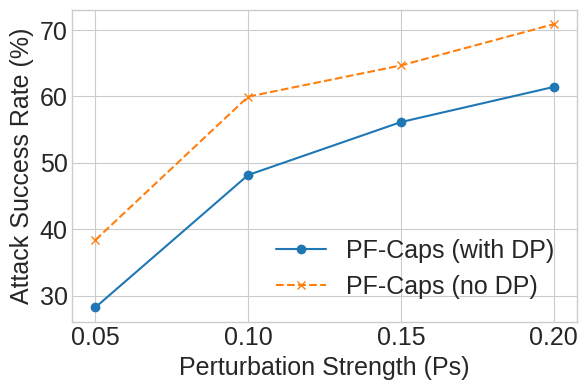

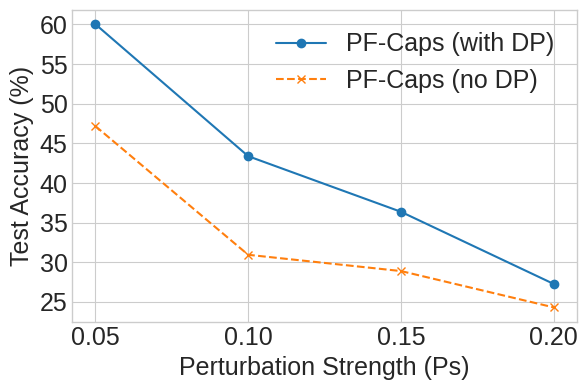

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('results/fgsm_attack_detailed_results.csv')

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Get unique model names and create aliases
model_names = df['model'].unique()
aliases = {}
if len(model_names) > 0:
    aliases[model_names[0]] = 'PF-Caps (with DP)'
if len(model_names) > 1:
    aliases[model_names[1]] = 'PF-Caps (no DP)'

# Separate data for each model
model1_data = df[df['model'] == model_names[0]] if len(model_names) > 0 else pd.DataFrame()
model2_data = df[df['model'] == model_names[1]] if len(model_names) > 1 else pd.DataFrame()

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
font_size = 18

# --- Plot 1: Attack Success Rate ---
plt.figure(figsize=(6, 4))
if not model1_data.empty:
    plt.plot(model1_data['epsilon'], model1_data['attack_success_rate'], marker='o', linestyle='-', label=aliases.get(model_names[0]))
if not model2_data.empty:
    plt.plot(model2_data['epsilon'], model2_data['attack_success_rate'], marker='x', linestyle='--', label=aliases.get(model_names[1]))

#plt.title('Attack Success Rate vs. Perturbation (Ps)', fontsize=font_size+2)
plt.xlabel('Perturbation Strength (Ps)', fontsize=font_size)
plt.ylabel('Attack Success Rate (%)', fontsize=font_size)
if not df.empty:
    plt.xticks(np.unique(df['epsilon']), fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)
plt.tight_layout()
plt.savefig('results/fgsm_attack_success_rate.pdf', bbox_inches='tight')
plt.show()

# --- Plot 2: Accuracy under attack ---
plt.figure(figsize=(6, 4))
if not model1_data.empty:
    plt.plot(model1_data['epsilon'], model1_data['accuracy'], marker='o', linestyle='-', label=aliases.get(model_names[0]))
if not model2_data.empty:
    plt.plot(model2_data['epsilon'], model2_data['accuracy'], marker='x', linestyle='--', label=aliases.get(model_names[1]))

#plt.title('Accuracy on Adversarial Examples vs. Perturbation (Ps)', fontsize=font_size+2)
plt.xlabel('Perturbation Strength (Ps)', fontsize=font_size)
plt.ylabel('Test Accuracy (%)', fontsize=font_size)
if not df.empty:
    plt.xticks(np.unique(df['epsilon']), fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)
plt.tight_layout()
plt.savefig('results/fgsm_attack_accuracy.pdf', bbox_inches='tight')
plt.show()

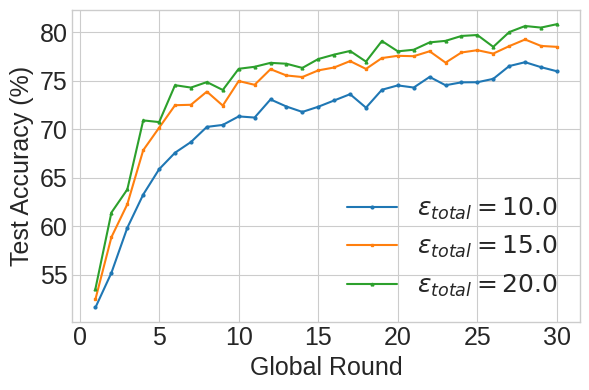

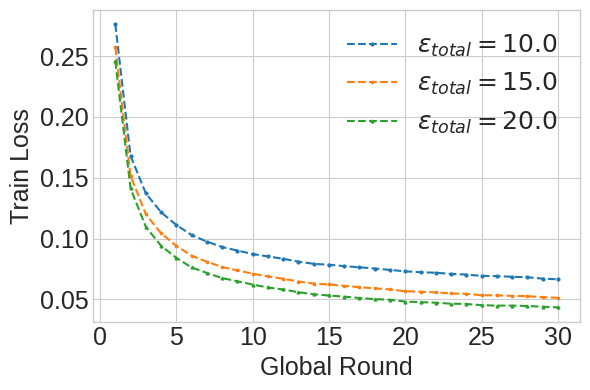

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths and labels
files = {
    r'$\epsilon_{total}=10.0$': 'results/rdp_ditto_caps_niid_0.2_4clients_lambda0.9_eps10.0_C3.0.csv',
    r'$\epsilon_{total}=15.0$': 'results/rdp_ditto_caps_niid_0.2_4clients_lambda0.9_eps15.0_C3.0.csv',
    r'$\epsilon_{total}=20.0$': 'results/rdp_ditto_caps_niid_0.2_4clients_lambda0.9_eps20.0_C3.0.csv'
}

# Read data into a dictionary of dataframes
data = {}
for label, path in files.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    data[label] = df

# Plotting style from the previous example
plt.style.use('seaborn-v0_8-whitegrid')
font_size = 18

# Define markers for each epsilon
markers = ['o', 's', '^']  # circle, square, triangle

# --- Plot 1: Test Accuracy ---
plt.figure(figsize=(6, 4))
for i, (label, df) in enumerate(data.items()):
    plt.plot(df['round'], df['global_test_accuracy'] * 100, linestyle='-', marker=markers[i], markersize=2, label=label)

plt.xlabel('Global Round', fontsize=font_size)
plt.ylabel('Test Accuracy (%)', fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)
plt.tight_layout()
plt.savefig('results/rdp_ditto_accuracy_vs_round.pdf', bbox_inches='tight')
plt.show()

# --- Plot 2: Train Loss ---
plt.figure(figsize=(6, 4))
for i, (label, df) in enumerate(data.items()):
    plt.plot(df['round'], df['train_loss'], linestyle='--', marker=markers[i],markersize=2, label=label)

plt.xlabel('Global Round', fontsize=font_size)
plt.ylabel('Train Loss', fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.legend(fontsize=font_size)
plt.grid(True)
plt.tight_layout()
plt.savefig('results/rdp_ditto_loss_vs_round.pdf', bbox_inches='tight')
plt.show()

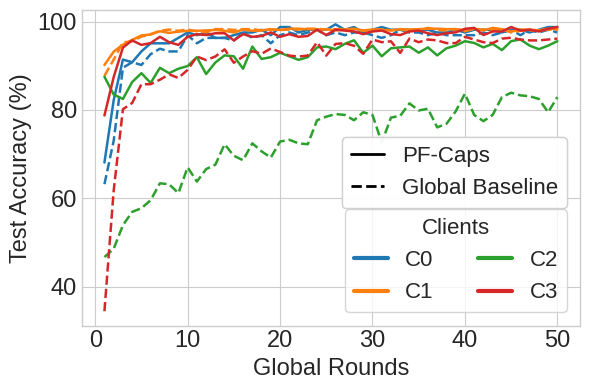

Saved: results/client_accuracies_singlefile.pdf


In [151]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- load data -----
csv_path = 'results/ditto_caps_niid_0.2_4clients_lambda0.9.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# coerce numerics and clean
for c in df.columns:
    if c != 'round':
        df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.sort_values('round').interpolate(limit_direction='both')

# detect columns / helpers
pers_cols   = sorted([c for c in df.columns if re.fullmatch(r'client_\d+_pers_acc',  c)])
global_cols = sorted([c for c in df.columns if re.fullmatch(r'client_\d+_global_acc', c)])
num_clients = min(len(pers_cols), len(global_cols))
rounds = df['round']

def to_percent(s):
    return s*100 if s.max() <= 1.0 else s

# ---- plot (with two concise legends, close to each other, very short icons) ----
fig, ax = plt.subplots(figsize=(6, 4))
cmap = plt.colormaps.get_cmap('tab10')
font_size = 17
for i in range(num_clients):
    pa = to_percent(df[pers_cols[i]])
    ga = to_percent(df[global_cols[i]])
    color = cmap(i)
    ax.plot(rounds, pa, color=color, linestyle='-',  linewidth=1.8)  # Personalized
    ax.plot(rounds, ga, color=color, linestyle='--', linewidth=1.8)  # Global

ax.set_xlabel('Global Rounds', fontsize=font_size)
ax.set_ylabel('Test Accuracy (%)', fontsize=font_size)
ax.tick_params(labelsize=font_size)
ax.grid(True)

from matplotlib.lines import Line2D
# Short legend lines by setting 'handlelength'
style_handles = [
    Line2D([0], [0], color='black', linestyle='-',  linewidth=2, label='PF-Caps'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Global Baseline'),
]

client_handles = [
    Line2D([0], [0], color=cmap(i), linestyle='-', linewidth=3, label=f'C{i}')
    for i in range(num_clients)
]

# Place legends close together: lower left and just above it
leg_clients = ax.legend(
    handles=client_handles,
    loc='lower right',
    ncol=2,
    fontsize=font_size-1,
    handlelength=1.5,
    borderaxespad=0.6,
    title='Clients',
    title_fontsize=font_size-1,  # Increase the size of the "Clients" title
    frameon=True
)
ax.add_artist(leg_clients)
leg_style = ax.legend(handles=style_handles, loc='lower right',bbox_to_anchor=(1, 0.33),
                      fontsize=font_size-1, handlelength=1.5, borderaxespad=0.6, frameon=True)
ax.add_artist(leg_style)

plt.tight_layout()
plt.savefig('results/client_accuracies_singlefile.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("Saved: results/client_accuracies_singlefile.pdf")


In [ ]:
# ---- plot (with two concise legends, close to each other, very short icons) ----
fig, ax = plt.subplots(figsize=(12, 14))
cmap = plt.colormaps.get_cmap('tab10')
font_size = 17
for i in range(num_clients):
    pa = to_percent(df[pers_cols[i]])
    ga = to_percent(df[global_cols[i]])
    color = cmap(i)
    ax.plot(rounds, pa, color=color, linestyle='-',  linewidth=1.8)  # Personalized
    ax.plot(rounds, ga, color=color, linestyle='--', linewidth=1.8)  # Global

ax.set_xlabel('Global Rounds', fontsize=font_size)
ax.set_ylabel('Accuracy (%)', fontsize=font_size)
ax.tick_params(labelsize=font_size)
ax.grid(True)

from matplotlib.lines import Line2D
# Short legend lines by setting 'handlelength'
style_handles = [
    Line2D([0], [0], color='black', linestyle='-',  linewidth=2, label='Personalized'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Global'),
]

client_handles = [
    Line2D([0], [0], color=cmap(i), linestyle='-', linewidth=3, label=f'C{i}')
    for i in range(num_clients)
]

# Place legends close together: lower left and just above it
leg_clients = ax.legend(
    handles=client_handles,
    loc='lower right',
    ncol=2,
    fontsize=font_size-1,
    handlelength=1.5,
    borderaxespad=0.6,
    title='Clients',
    title_fontsize=font_size-1,  # Increase the size of the "Clients" title
    frameon=True
)
ax.add_artist(leg_clients)
leg_style = ax.legend(handles=style_handles, loc='lower right',bbox_to_anchor=(1, 0.33),
                      fontsize=font_size-1, handlelength=1.5, borderaxespad=0.6, frameon=True)
ax.add_artist(leg_style)

plt.tight_layout()
plt.savefig('results/client_accuracies_singlefile_Zoomed.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("Saved: results/client_accuracies_singlefile.pdf")


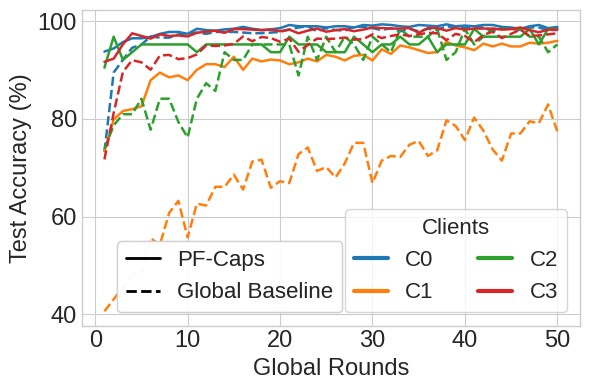

Saved: results/client_accuracies_singlefile.pdf


In [215]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- load data -----
csv_path = 'results/ditto_caps_niid_0.1_4clients_lambda0.9.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# coerce numerics and clean
for c in df.columns:
    if c != 'round':
        df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.sort_values('round').interpolate(limit_direction='both')

# detect columns / helpers
pers_cols   = sorted([c for c in df.columns if re.fullmatch(r'client_\d+_pers_acc',  c)])
global_cols = sorted([c for c in df.columns if re.fullmatch(r'client_\d+_global_acc', c)])
num_clients = min(len(pers_cols), len(global_cols))
rounds = df['round']

def to_percent(s):
    return s*100 if s.max() <= 1.0 else s

# ---- plot (with two concise legends, close to each other, very short icons) ----
fig, ax = plt.subplots(figsize=(6, 4))
cmap = plt.colormaps.get_cmap('tab10')
font_size = 17
for i in range(num_clients):
    pa = to_percent(df[pers_cols[i]])
    ga = to_percent(df[global_cols[i]])
    color = cmap(i)
    ax.plot(rounds, pa, color=color, linestyle='-',  linewidth=1.8)  # Personalized
    ax.plot(rounds, ga, color=color, linestyle='--', linewidth=1.8)  # Global

ax.set_xlabel('Global Rounds', fontsize=font_size)
ax.set_ylabel('Test Accuracy (%)', fontsize=font_size)
ax.tick_params(labelsize=font_size)
ax.grid(True)

from matplotlib.lines import Line2D
# Short legend lines by setting 'handlelength'
style_handles = [
    Line2D([0], [0], color='black', linestyle='-',  linewidth=2, label='PF-Caps'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Global Baseline'),
]

client_handles = [
    Line2D([0], [0], color=cmap(i), linestyle='-', linewidth=3, label=f'C{i}')
    for i in range(num_clients)
]

# Place legends close together: lower left and just above it
leg_clients = ax.legend(
    handles=client_handles,
    loc='lower right',
    ncol=2,
    fontsize=font_size-1,
    handlelength=1.5,
    borderaxespad=0.6,
    title='Clients',
    title_fontsize=font_size-1,  # Increase the size of the "Clients" title
    frameon=True
)
ax.add_artist(leg_clients)
leg_style = ax.legend(handles=style_handles, loc='lower right',bbox_to_anchor=(0.55, 0.0),
                      fontsize=font_size-1, handlelength=1.5, borderaxespad=0.6, frameon=True)
ax.add_artist(leg_style)

plt.tight_layout()
plt.savefig('results/client_accuracies_singlefile_niid_0.1.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("Saved: results/client_accuracies_singlefile.pdf")


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- load data -----
csv_path = 'results/ditto_caps_niid_0.1_4clients_lambda0.9.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# coerce numerics and clean
for c in df.columns:
    if c != 'round':
        df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.sort_values('round').interpolate(limit_direction='both')

# detect columns / helpers
pers_cols   = sorted([c for c in df.columns if re.fullmatch(r'client_\d+_pers_acc',  c)])
global_cols = sorted([c for c in df.columns if re.fullmatch(r'client_\d+_global_acc', c)])
num_clients = min(len(pers_cols), len(global_cols))
rounds = df['round']

def to_percent(s):
    return s*100 if s.max() <= 1.0 else s

# ---- plot (with two concise legends, close to each other, very short icons) ----
fig, ax = plt.subplots(figsize=(12, 14))
cmap = plt.colormaps.get_cmap('tab10')
font_size = 17
for i in range(num_clients):
    pa = to_percent(df[pers_cols[i]])
    ga = to_percent(df[global_cols[i]])
    color = cmap(i)
    ax.plot(rounds, pa, color=color, linestyle='-',  linewidth=1.8)  # Personalized
    ax.plot(rounds, ga, color=color, linestyle='--', linewidth=1.8)  # Global

ax.set_xlabel('Global Rounds', fontsize=font_size)
ax.set_ylabel('Test Accuracy (%)', fontsize=font_size)
ax.tick_params(labelsize=font_size)
ax.grid(True)

from matplotlib.lines import Line2D
# Short legend lines by setting 'handlelength'
style_handles = [
    Line2D([0], [0], color='black', linestyle='-',  linewidth=2, label='Personalized'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Global'),
]

client_handles = [
    Line2D([0], [0], color=cmap(i), linestyle='-', linewidth=3, label=f'C{i}')
    for i in range(num_clients)
]

# Place legends close together: lower left and just above it
leg_clients = ax.legend(
    handles=client_handles,
    loc='lower right',
    ncol=2,
    fontsize=font_size-1,
    handlelength=1.5,
    borderaxespad=0.6,
    title='Clients',
    title_fontsize=font_size-1,  # Increase the size of the "Clients" title
    frameon=True
)
ax.add_artist(leg_clients)
leg_style = ax.legend(handles=style_handles, loc='lower right',bbox_to_anchor=(1, 0.33),
                      fontsize=font_size-1, handlelength=1.5, borderaxespad=0.6, frameon=True)
ax.add_artist(leg_style)

plt.tight_layout()
plt.savefig('results/client_accuracies_singlefile_niid_0.1_zoomed.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("Saved: results/client_accuracies_singlefile.pdf")


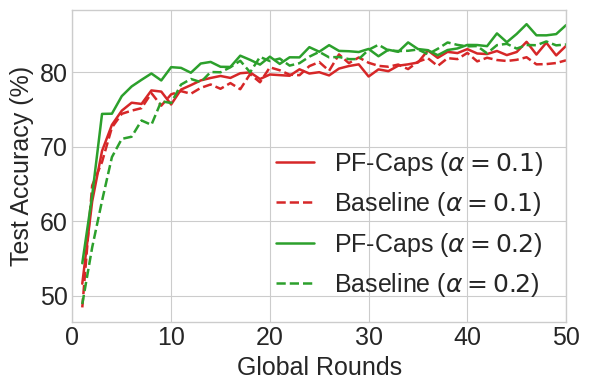

Saved: results/global_accuracies_both_niid.pdf


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- files ----
ditto_01 = 'results/ditto_caps_niid_0.1_4clients_lambda0.9.csv'
fed_01   = 'results/fed_caps_niid_0.1_4clients_frac0.3.csv'
ditto_02 = 'results/ditto_caps_niid_0.2_4clients_lambda0.9.csv'
fed_02   = 'results/fed_caps_niid_0.2_4clients_frac0.3.csv'

# ---- load & clean ----
def load_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    # Ensure 'round' column is integer for axis ops
    df['round'] = pd.to_numeric(df['round'], errors='coerce').astype('Int64')
    return df.sort_values('round')

d01 = load_csv(ditto_01)
f01 = load_csv(fed_01)
d02 = load_csv(ditto_02)
f02 = load_csv(fed_02)

# Some FedAvg logs use 'global_test_accuracy' instead of 'test_accuracy'
def fed_acc(df):
    return df['test_accuracy'] if 'test_accuracy' in df.columns else df['global_test_accuracy']

# Scale to % if needed
def to_percent(s):
    s = pd.to_numeric(s, errors='coerce')
    return s*100 if s.max() is not None and s.max() <= 1.0 else s

font_size = 18

# ---- plot ----
fig, ax = plt.subplots(figsize=(6, 4))

# Red for alpha=0.1, green for alpha=0.2. Style for personalized vs non.
color_01 = "#d62728"   # red
color_02 = "#2ca02c"   # green

ax.plot(
    d01['round'], to_percent(d01['global_test_accuracy']),
    color=color_01, linestyle='-', linewidth=1.8,
    label=r'PF-Caps ($\alpha=0.1$)'
)
ax.plot(
    f01['round'], to_percent(fed_acc(f01)),
    color=color_01, linestyle='--', linewidth=1.8,
    label=r'Baseline ($\alpha=0.1$)'
)
ax.plot(
    d02['round'], to_percent(d02['global_test_accuracy']),
    color=color_02, linestyle='-', linewidth=1.8,
    label=r'PF-Caps ($\alpha=0.2$)'
)
ax.plot(
    f02['round'], to_percent(fed_acc(f02)),
    color=color_02, linestyle='--', linewidth=1.8,
    label=r'Baseline ($\alpha=0.2$)'
)

ax.set_xlabel('Global Rounds', fontsize=font_size)
ax.set_ylabel('Test Accuracy (%)', fontsize=font_size)
ax.tick_params(labelsize=font_size)
ax.grid(True)

ax.legend(fontsize=font_size, ncol=1, handlelength=1.5, markerscale=0.8)

# ---- add xlim range and step size ----
all_rounds = pd.concat([
    d01['round'],
    f01['round'],
    d02['round'],
    f02['round']
]).dropna().astype(int)
xlim_min = int(all_rounds.min())
xlim_max = int(all_rounds.max())
step_size = 10  # Example step size, can be set as needed

ax.set_xlim(xlim_min, xlim_max)
ax.set_xticks(np.arange(0, 51, step_size))

plt.tight_layout()
plt.savefig('results/global_accuracies_both_niid.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("Saved: results/global_accuracies_both_niid.pdf")


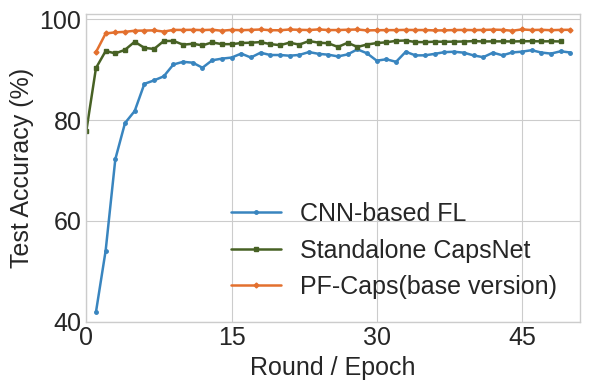

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

font_size = 18

# Use distinctive color palette for CNN and PF-Caps and single-site CapsNet
color_cnn = "#3985bf"    # blueish for CNN
color_caps = "#e3702e"   # orange for PF-Caps
color_single_caps = "#476124" # green for single-site CapsNet

# Use distinctive markers for each line
marker_cnn = 'o'         # circle for CNN
marker_caps = 'D'        # diamond for PF-Caps
marker_single_caps = 's' # square for single-site CapsNet
marker_size = 2.5

# Load
cnn_df  = pd.read_csv('cnn/results/fed_cnn_iid_10clients_frac0.3.csv')
caps_df = pd.read_csv('results/fed_caps_iid_4clients_frac0.4.csv')
single_caps_df = pd.read_csv('training_log_frac0.1.csv')

for df in (cnn_df, caps_df):
    df.columns = df.columns.str.strip()
    df.sort_values('round', inplace=True)

single_caps_df.columns = single_caps_df.columns.str.strip()
single_caps_df.sort_values('epoch', inplace=True)

def to_percent(s):
    s = pd.to_numeric(s, errors='coerce')
    return s*100 if s.max() is not None and s.max() <= 1.0 else s

r1, r2      = cnn_df['round'], caps_df['round']
acc_cnn     = to_percent(cnn_df['val_accuracy'])
acc_caps    = to_percent(caps_df['val_accuracy'])

single_caps_epochs = single_caps_df['epoch']
single_caps_acc = to_percent(single_caps_df['val_acc'])

# ---- figure ----
fig, ax = plt.subplots(figsize=(6, 4))

# Plot accuracy — solid for both, different color and markers
p1, = ax.plot(
    r1, acc_cnn, linestyle='-', linewidth=1.8, color=color_cnn, 
    label='CNN-based FL', marker=marker_cnn, markersize=marker_size
)
p3, = ax.plot(
    single_caps_epochs, single_caps_acc, linestyle='-', linewidth=1.8, color=color_single_caps,
    label='Standalone CapsNet', marker=marker_single_caps, markersize=marker_size
)
p2, = ax.plot(
    r2, acc_caps, linestyle='-', linewidth=1.8, color=color_caps, 
    label='PF-Caps(base version)', marker=marker_caps, markersize=marker_size
)


# ---- X axis ----
xmin, xmax = 0, 51
xticks = np.arange(xmin, xmax + 1, 15)
ax.set_xlim(xmin, xmax)
ax.set_xticks(xticks)

# ---- Y axis ----
acc_min, acc_max = 40, 101.0
acc_ticks = np.arange(40, 101, 20)
ax.set_ylim(acc_min, acc_max)
ax.set_yticks(acc_ticks)

ax.set_xlabel('Round / Epoch', fontsize=font_size)
ax.set_ylabel('Validation Accuracy (%)', fontsize=font_size)

ax.tick_params(labelsize=font_size)
ax.grid(True)

ax.legend(fontsize=font_size, ncol=1, loc='best')

plt.tight_layout()
plt.savefig('results/accuracy_comparison_caps_cnn.pdf', bbox_inches='tight')
plt.show()


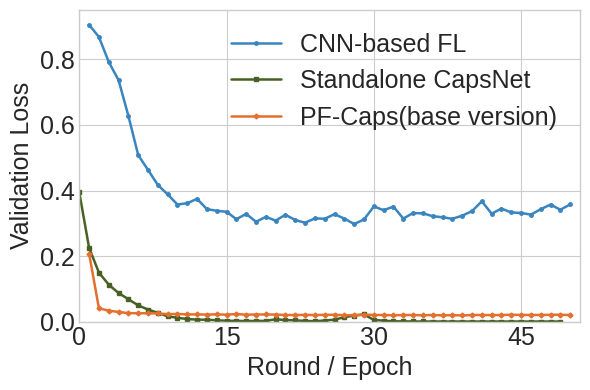

In [187]:
# --- pick loss columns with fallback ---
def get_loss(df, prefer='val_loss', fallback='loss'):
    col = prefer if prefer in df.columns else fallback
    return pd.to_numeric(df[col], errors='coerce')

loss_cnn        = get_loss(cnn_df)          # val_loss or test_loss
loss_caps       = get_loss(caps_df)         # val_loss or test_loss
single_caps_loss= get_loss(single_caps_df)  # val_loss or test_loss

# ---- figure (loss) ----
fig, ax = plt.subplots(figsize=(6, 4))

# Plot loss — same colors/markers, solid lines
ax.plot(
    r1, loss_cnn, linestyle='-', linewidth=1.8, color=color_cnn,
    label='CNN-based FL', marker=marker_cnn, markersize=marker_size
)
ax.plot(
    single_caps_epochs, single_caps_loss, linestyle='-', linewidth=1.8, color=color_single_caps,
    label='Standalone CapsNet', marker=marker_single_caps, markersize=marker_size
)
ax.plot(
    r2, loss_caps, linestyle='-', linewidth=1.8, color=color_caps,
    label='PF-Caps(base version)', marker=marker_caps, markersize=marker_size
)

# ---- X axis (same as accuracy plot) ----
xmin, xmax = 0, 51
xticks = np.arange(xmin, xmax + 1, 15)
ax.set_xlim(xmin, xmax)
ax.set_xticks(xticks)

# ---- Y axis (loss) ----
# auto-range with a clean baseline at 0
ymin = 0.0
ymax = float(np.nanmax([loss_cnn.max(), loss_caps.max(), single_caps_loss.max()])) * 1.05
ax.set_ylim(ymin, ymax)

ax.set_xlabel('Round / Epoch', fontsize=font_size)
ax.set_ylabel('Validation Loss', fontsize=font_size)

ax.tick_params(labelsize=font_size)
ax.grid(True)

ax.legend(fontsize=font_size, ncol=1, loc='best')

plt.tight_layout()
plt.savefig('results/loss_comparison_caps_cnn.pdf', bbox_inches='tight')
plt.show()


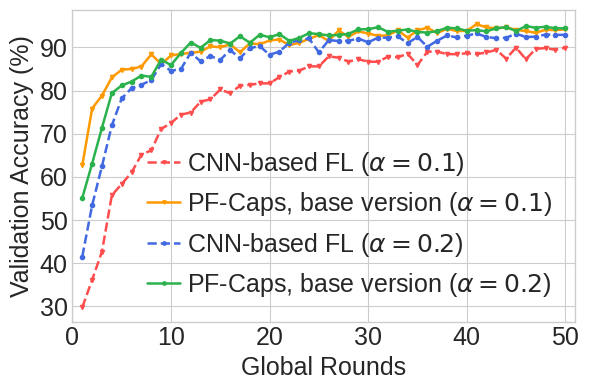

In [224]:
import pandas as pd
import matplotlib.pyplot as plt

font_size = 18

# Four different colors for each line and mapping to display/legend/plot labels
files_to_plot = {
    "FedCNN NIID 0.1":  {"path": "cnn/results/fed_cnn_niid_0.1_10clients_frac0.3.csv", "color": "#FF4D4D",
                         "plot_label": r"CNN-based FL ($\alpha=0.1$)"},
    "FedCaps NIID 0.1": {"path": "results/fed_caps_niid_0.1_4clients_frac0.3.csv",      "color": "#FF9900",
                         "plot_label": r"PF-Caps, base version ($\alpha=0.1$)"},
    "FedCNN NIID 0.2":  {"path": "cnn/results/fed_cnn_niid_0.2_10clients_frac0.3.csv", "color": "#4169E1",
                         "plot_label": r"CNN-based FL ($\alpha=0.2$)"},
    "FedCaps NIID 0.2": {"path": "results/fed_caps_niid_0.2_4clients_frac0.3.csv",      "color": "#2BB24C",
                         "plot_label": r"PF-Caps, base version ($\alpha=0.2$)"},
}

# Map (display) plot_label -> style
style_map = {
    r"CNN-based FL ($\alpha=0.1$)":  dict(linestyle="--", marker="v"),
    r"PF-Caps, base version ($\alpha=0.1$)": dict(linestyle="-",  marker="v"),
    r"CNN-based FL ($\alpha=0.2$)":  dict(linestyle="--", marker="o"),
    r"PF-Caps, base version ($\alpha=0.2$)": dict(linestyle="-",  marker="o"),
}

plt.figure(figsize=(6,4))

for label, d in files_to_plot.items():
    path = d["path"]
    color = d["color"]
    plot_label = d["plot_label"]
    df = pd.read_csv(path)
    # Discard last row if it contains 'best_model_test'
    if any(df.astype(str).iloc[-1].str.contains('best_model_test')):
        df = df.iloc[:-1]
    acc_percent = df['val_accuracy'] * 100
    # Use plot_label to index style_map, not 'label'
    plt.plot(
        df['round'],
        acc_percent,
        label=plot_label,
        color=color,
        marker=style_map[plot_label]['marker'],
        linestyle=style_map[plot_label]['linestyle'],
        linewidth=1.8,
        markersize=3
    )

plt.xlabel('Global Rounds', fontsize=font_size)
plt.ylabel('Validation Accuracy (%)', fontsize=font_size)
plt.xlim(0, 51)
plt.xticks(range(0, 52, 10), fontsize=font_size)
plt.yticks(fontsize=font_size)

# Custom legend with smaller handlelength, handletextpad, and markerscale
plt.legend(
    fontsize=font_size, 
    loc='lower right', 
    handlelength=1.3,        # reduce icon length
    handletextpad=0.3,       # reduce gap between icon and text
    borderaxespad=0.5, 
    markerscale=0.8          # reduce icon size
)
plt.grid(True)
plt.tight_layout()
plt.savefig('results/accuracy_comparison_caps_cnn_noniid.pdf', bbox_inches='tight')
plt.show()


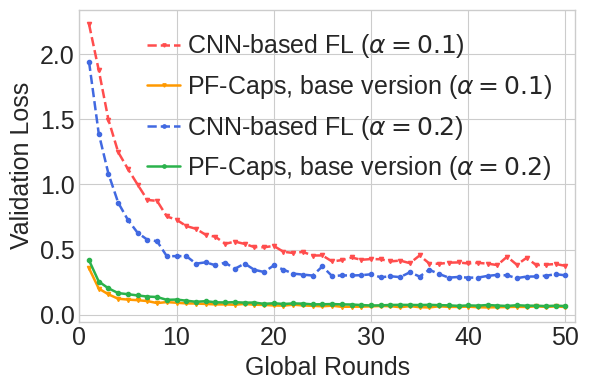

In [225]:
import pandas as pd
import matplotlib.pyplot as plt

font_size = 18

# Four different colors for each line and mapping to display/legend/plot labels
files_to_plot = {
    "FedCNN NIID 0.1":  {"path": "cnn/results/fed_cnn_niid_0.1_10clients_frac0.3.csv", "color": "#FF4D4D",
                         "plot_label": r"CNN-based FL ($\alpha=0.1$)"},
    "FedCaps NIID 0.1": {"path": "results/fed_caps_niid_0.1_4clients_frac0.3.csv",      "color": "#FF9900",
                         "plot_label": r"PF-Caps, base version ($\alpha=0.1$)"},
    "FedCNN NIID 0.2":  {"path": "cnn/results/fed_cnn_niid_0.2_10clients_frac0.3.csv", "color": "#4169E1",
                         "plot_label": r"CNN-based FL ($\alpha=0.2$)"},
    "FedCaps NIID 0.2": {"path": "results/fed_caps_niid_0.2_4clients_frac0.3.csv",      "color": "#2BB24C",
                         "plot_label": r"PF-Caps, base version ($\alpha=0.2$)"},
}

# Map (display) plot_label -> style
style_map = {
    r"CNN-based FL ($\alpha=0.1$)":  dict(linestyle="--", marker="v"),
    r"PF-Caps, base version ($\alpha=0.1$)": dict(linestyle="-",  marker="v"),
    r"CNN-based FL ($\alpha=0.2$)":  dict(linestyle="--", marker="o"),
    r"PF-Caps, base version ($\alpha=0.2$)": dict(linestyle="-",  marker="o"),
}

# Helper to pick the right loss column
def pick_loss_series(df):
    for col in ("val_loss", "test_loss", "train_loss"):
        if col in df.columns:
            return pd.to_numeric(df[col], errors="coerce")
    raise KeyError("No loss column found (expected one of: 'val_loss', 'test_loss', 'train_loss').")

plt.figure(figsize=(6,4))

for label, d in files_to_plot.items():
    path = d["path"]
    color = d["color"]
    plot_label = d["plot_label"]

    df = pd.read_csv(path)
    # Discard last row if it contains 'best_model_test'
    if any(df.astype(str).iloc[-1].str.contains('best_model_test', na=False)):
        df = df.iloc[:-1]

    loss_series = pick_loss_series(df)

    # Use plot_label to index style_map, not 'label'
    plt.plot(
        df['round'],
        loss_series,
        label=plot_label,
        color=color,
        marker=style_map[plot_label]['marker'],
        linestyle=style_map[plot_label]['linestyle'],
        linewidth=1.8,
        markersize=3
    )

plt.xlabel('Global Rounds', fontsize=font_size)
plt.ylabel('Validation Loss', fontsize=font_size)
plt.xlim(0, 51)
plt.xticks(range(0, 52, 10), fontsize=font_size)
plt.yticks(fontsize=font_size)

# Custom legend with smaller handlelength, handletextpad, and markerscale
plt.legend(
    fontsize=font_size, 
    loc='upper right',          # put loss legend top-right to avoid overlap (tweak if needed)
    handlelength=1.3,
    handletextpad=0.3,
    borderaxespad=0.5,
    markerscale=0.8
)

plt.grid(True)
plt.tight_layout()
plt.savefig('results/loss_comparison_caps_cnn_noniid.pdf', bbox_inches='tight')
plt.show()
